In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df_hazard1  = pd.read_excel("/content/pricing_cargo_loss (4).xlsx", sheet_name = "segment_summary")

In [ ]:
df_hazard1  = pd.read_excel("/content/pricing_worker_compensation (1).xlsx", sheet_name = "segment_summary")

 AGGREGATE LOSS DISTRIBUTION (PV) — Cargo Loss

[1] Overview Data (Nominal)
    Jumlah group    : 96
    Total Klaim     :        1,159,792,847
    Total Premi     :        1,799,283,466

[2] Running Bootstrap Simulation (100,000 iterations)...

 PORTFOLIO METRICS (PRESENT VALUE)
  PV Observed Loss         :        1,112,433,866
  PV Total Earned Premium  :        1,725,811,525
-----------------------------------------------------------------
  Simulated E[Loss] PV     :        1,113,601,006
  VaR 99% (p99) PV         :        1,632,014,956
  TVaR 99% PV              :        1,713,081,877
  P(Loss > Premium) [Ruin] :               0.32%
  Capital Required (p99-μ) :          518,413,950


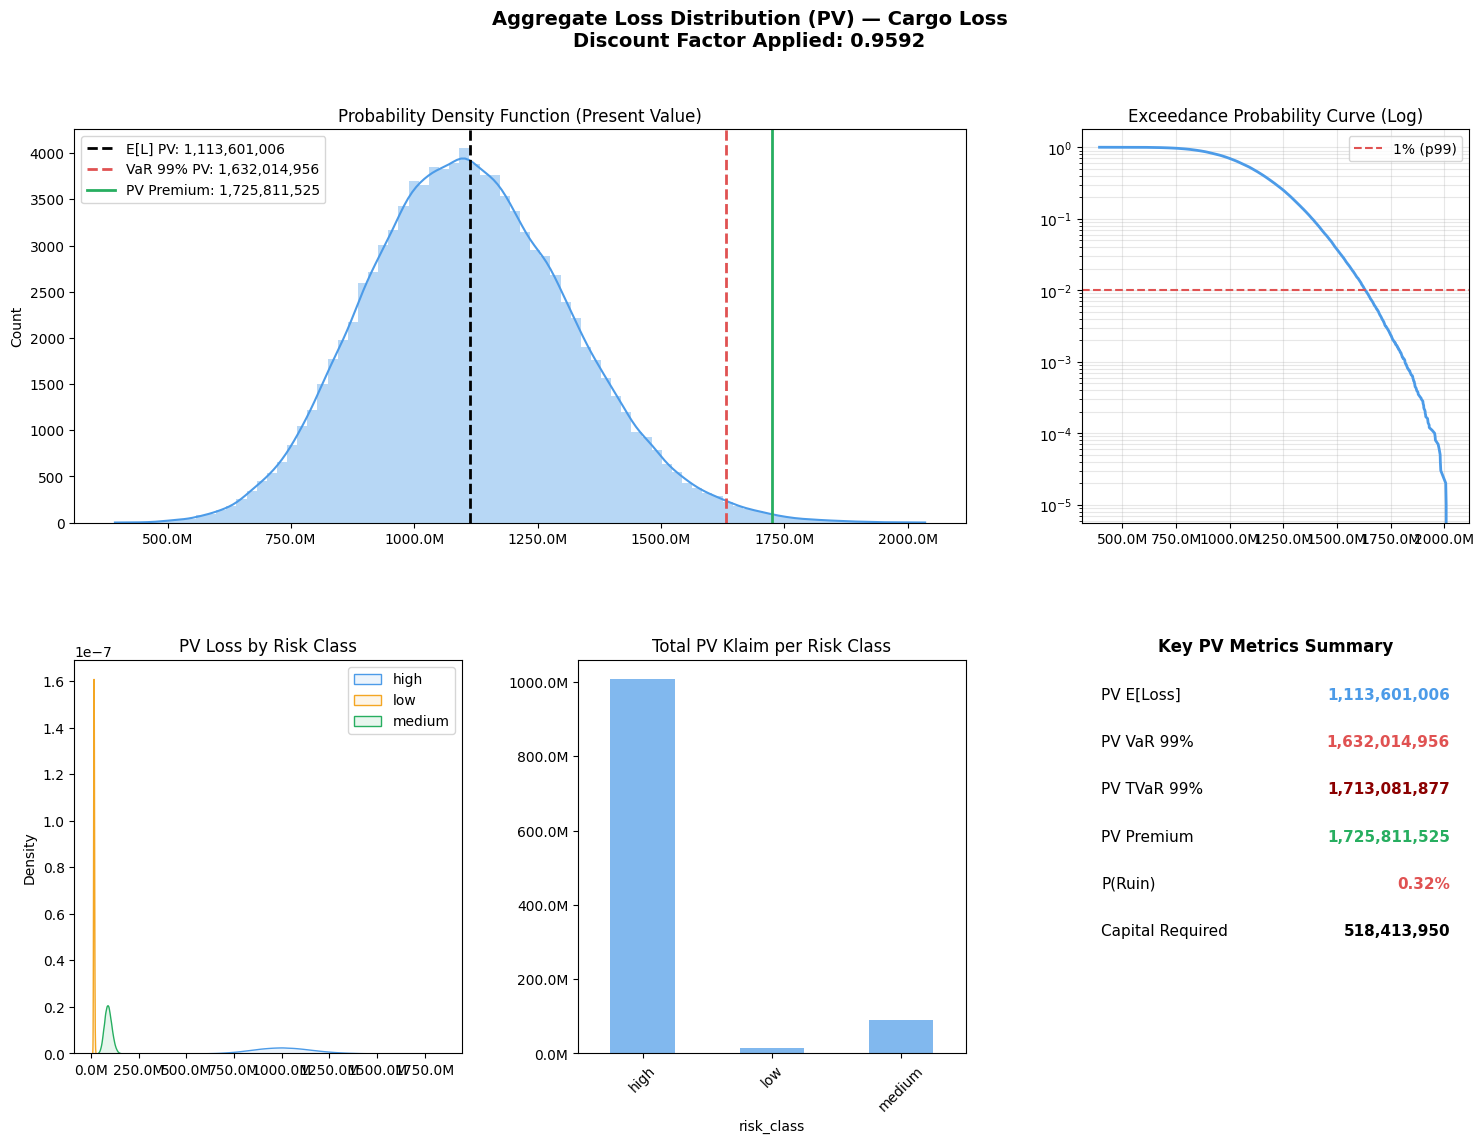

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# =============================================================================
# 1. KONFIGURASI & INPUT DATA
# =============================================================================
HAZARD_NAME = "Cargo Loss"
N_SIM       = 100_000
SEED        = 42
np.random.seed(SEED)

# ASUMSI: df_hazard1 sudah ter-load di environment kamu.
# Jika belum, pastikan kamu sudah menjalankan cell yang mendefinisikan df_hazard1.

# Masukkan Discount Factor untuk tahun target (Misal tahun 2190)
DISCOUNT_FACTOR_2190 = 0.959166

# =============================================================================
# 2. VALIDASI DATA AWAL
# =============================================================================
print("=" * 65)
print(f" AGGREGATE LOSS DISTRIBUTION (PV) — {HAZARD_NAME}")
print("=" * 65)

obs_loss_nominal = df_hazard1['Klaim'].sum()
total_premi_nominal = df_hazard1['Earned Premi'].sum()

print(f"\n[1] Overview Data (Nominal)")
print(f"    Jumlah group    : {len(df_hazard1)}")
print(f"    Total Klaim     : {obs_loss_nominal:>20,.0f}")
print(f"    Total Premi     : {total_premi_nominal:>20,.0f}")

# =============================================================================
# 3. BOOTSTRAP SIMULATION
# =============================================================================
print(f"\n[2] Running Bootstrap Simulation ({N_SIM:,} iterations)...")

klaim_values = df_hazard1['Klaim'].values
n_groups     = len(klaim_values)

# Bootstrap Aggregate Portfolio (Nominal)
agg_losses_nominal = np.array([
    np.random.choice(klaim_values, size=n_groups, replace=True).sum()
    for _ in range(N_SIM)
])

# KONVERSI KE PRESENT VALUE (PV)
agg_losses_pv = agg_losses_nominal * DISCOUNT_FACTOR_2190

# Bootstrap per risk_class (PV)
seg_losses_pv = {}
for rc in sorted(df_hazard1['risk_class'].unique()):
    vals = df_hazard1[df_hazard1['risk_class'] == rc]['Klaim'].values
    n    = len(vals)
    seg_losses_pv[rc] = np.array([
        np.random.choice(vals, size=n, replace=True).sum()
        for _ in range(N_SIM)
    ]) * DISCOUNT_FACTOR_2190

# =============================================================================
# 4. CALCULATE METRICS (BASED ON PV)
# =============================================================================
# Kita hitung semua metrik berdasarkan nilai yang sudah didiskon
obs_loss_pv   = obs_loss_nominal * DISCOUNT_FACTOR_2190
total_premi_pv = total_premi_nominal * DISCOUNT_FACTOR_2190

mean_loss_pv = agg_losses_pv.mean()
std_loss_pv  = agg_losses_pv.std()
p95_pv       = np.percentile(agg_losses_pv, 95)
p99_pv       = np.percentile(agg_losses_pv, 99)
p995_pv      = np.percentile(agg_losses_pv, 99.5)

tvar95_pv    = agg_losses_pv[agg_losses_pv >= p95_pv].mean()
tvar99_pv    = agg_losses_pv[agg_losses_pv >= p99_pv].mean()
prob_ruin    = (agg_losses_pv > total_premi_pv).mean()
req_capital  = p99_pv - mean_loss_pv
cov          = std_loss_pv / mean_loss_pv

print("\n" + "=" * 65)
print(" PORTFOLIO METRICS (PRESENT VALUE)")
print("=" * 65)
print(f"  PV Observed Loss         : {obs_loss_pv:>20,.0f}")
print(f"  PV Total Earned Premium  : {total_premi_pv:>20,.0f}")
print("-" * 65)
print(f"  Simulated E[Loss] PV     : {mean_loss_pv:>20,.0f}")
print(f"  VaR 99% (p99) PV         : {p99_pv:>20,.0f}")
print(f"  TVaR 99% PV              : {tvar99_pv:>20,.0f}")
print(f"  P(Loss > Premium) [Ruin] : {prob_ruin:>19.2%}")
print(f"  Capital Required (p99-μ) : {req_capital:>20,.0f}")
print("=" * 65)

# =============================================================================
# 5. VISUALISASI
# =============================================================================
BLUE, RED, GREEN, ORANGE, PURPLE, GRAY = '#4C9BE8', '#E05252', '#27AE60', '#F4A623', '#9B59B6', '#888888'

fig = plt.figure(figsize=(18, 12))
fig.suptitle(f"Aggregate Loss Distribution (PV) — {HAZARD_NAME}\n"
             f"Discount Factor Applied: {DISCOUNT_FACTOR_2190:.4f}", fontsize=14, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.3)
fmt = plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')

# --- Plot 1: PDF Aggregate Loss (PV) ---
ax1 = fig.add_subplot(gs[0, :2])
sns.histplot(agg_losses_pv, bins=80, kde=True, ax=ax1, color=BLUE, alpha=0.4, edgecolor='none')
ax1.axvline(mean_loss_pv, color='black', lw=2, ls='--', label=f'E[L] PV: {mean_loss_pv:,.0f}')
ax1.axvline(p99_pv, color=RED, lw=2, ls='--', label=f'VaR 99% PV: {p99_pv:,.0f}')
ax1.axvline(total_premi_pv, color=GREEN, lw=2, label=f'PV Premium: {total_premi_pv:,.0f}')
ax1.set_title('Probability Density Function (Present Value)', fontsize=12)
ax1.xaxis.set_major_formatter(fmt)
ax1.legend()

# --- Plot 2: Exceedance Probability (Log Scale) ---
ax2 = fig.add_subplot(gs[0, 2])
sorted_pv = np.sort(agg_losses_pv)
survival = 1 - np.arange(1, len(sorted_pv) + 1) / len(sorted_pv)
ax2.plot(sorted_pv, survival, color=BLUE, lw=2)
ax2.axhline(0.01, color=RED, ls='--', label='1% (p99)')
ax2.set_yscale('log')
ax2.set_title('Exceedance Probability Curve (Log)', fontsize=12)
ax2.xaxis.set_major_formatter(fmt)
ax2.grid(True, alpha=0.3, which='both')
ax2.legend()

# --- Plot 3: Distribution per Risk Class ---
ax3 = fig.add_subplot(gs[1, 0])
colors = [BLUE, ORANGE, GREEN, PURPLE, RED]
for i, (rc, losses) in enumerate(seg_losses_pv.items()):
    sns.kdeplot(losses, ax=ax3, label=rc, color=colors[i % len(colors)], fill=True, alpha=0.1)
ax3.set_title('PV Loss by Risk Class', fontsize=12)
ax3.xaxis.set_major_formatter(fmt)
ax3.legend()

# --- Plot 4: Breakdown Bar Chart ---
ax4 = fig.add_subplot(gs[1, 1])
rc_summary = df_hazard1.groupby('risk_class')['Klaim'].sum() * DISCOUNT_FACTOR_2190
rc_summary.plot(kind='bar', ax=ax4, color=BLUE, alpha=0.7)
ax4.set_title('Total PV Klaim per Risk Class', fontsize=12)
ax4.yaxis.set_major_formatter(fmt)
plt.xticks(rotation=45)

# --- Plot 5: Metrics Summary Table ---
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis('off')
metrics_text = [
    ("PV E[Loss]", f"{mean_loss_pv:,.0f}", BLUE),
    ("PV VaR 99%", f"{p99_pv:,.0f}", RED),
    ("PV TVaR 99%", f"{tvar99_pv:,.0f}", '#8B0000'),
    ("Total Premium", f"{total_premi:,.0f}", GREEN),
    ("P(Ruin)", f"{prob_ruin:.2%}", RED),
    ("Capital Required", f"{req_capital:,.0f}", 'black')
]
y_pos = 0.9
for label, val, col in metrics_text:
    ax5.text(0.05, y_pos, label, fontsize=11)
    ax5.text(0.95, y_pos, val, fontsize=11, fontweight='bold', color=col, ha='right')
    y_pos -= 0.12
ax5.set_title('Key PV Metrics Summary', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()